# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
penguins = sns.load_dataset('penguins')

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [4]:
# missing
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [5]:
penguins.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


Os campos categóricos devem ser excluídos da base, pois o modelo k-means não opera nesse tipo de dado. O campo `sex` não será excluído, mas transformado em numérico (binário). 

In [6]:
penguins.drop(['species', 'island'], inplace=True, axis=1)

In [7]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   bill_depth_mm      342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                333 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [8]:
print("Campos com dados ausentes:\n")
for campo in penguins:
    ausente =  penguins.count().max() - penguins[campo].count()
    print(campo, ausente) if (ausente) != 0 else None

print(f"\nCampos com valores nulos: {penguins.isnull().sum()}")

Campos com dados ausentes:

sex 9

Campos com valores nulos: bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


Como solicitado no exercício, excluir os valores nulos:

In [9]:
penguins.dropna(inplace=True)

Transformar o cmapo `sex` em numérica por meio do  Label Enconding.
O valor 1 será atribuído a 'Male', enquanto o valor 0 será atribuído a 'Female'.

In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
penguins['sex_encoded'] = label_encoder.fit_transform(penguins['sex'])
penguins.drop('sex', axis=1, inplace=True)
print(penguins.head(2))

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  sex_encoded
0            39.1           18.7              181.0       3750.0            1
1            39.5           17.4              186.0       3800.0            0


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

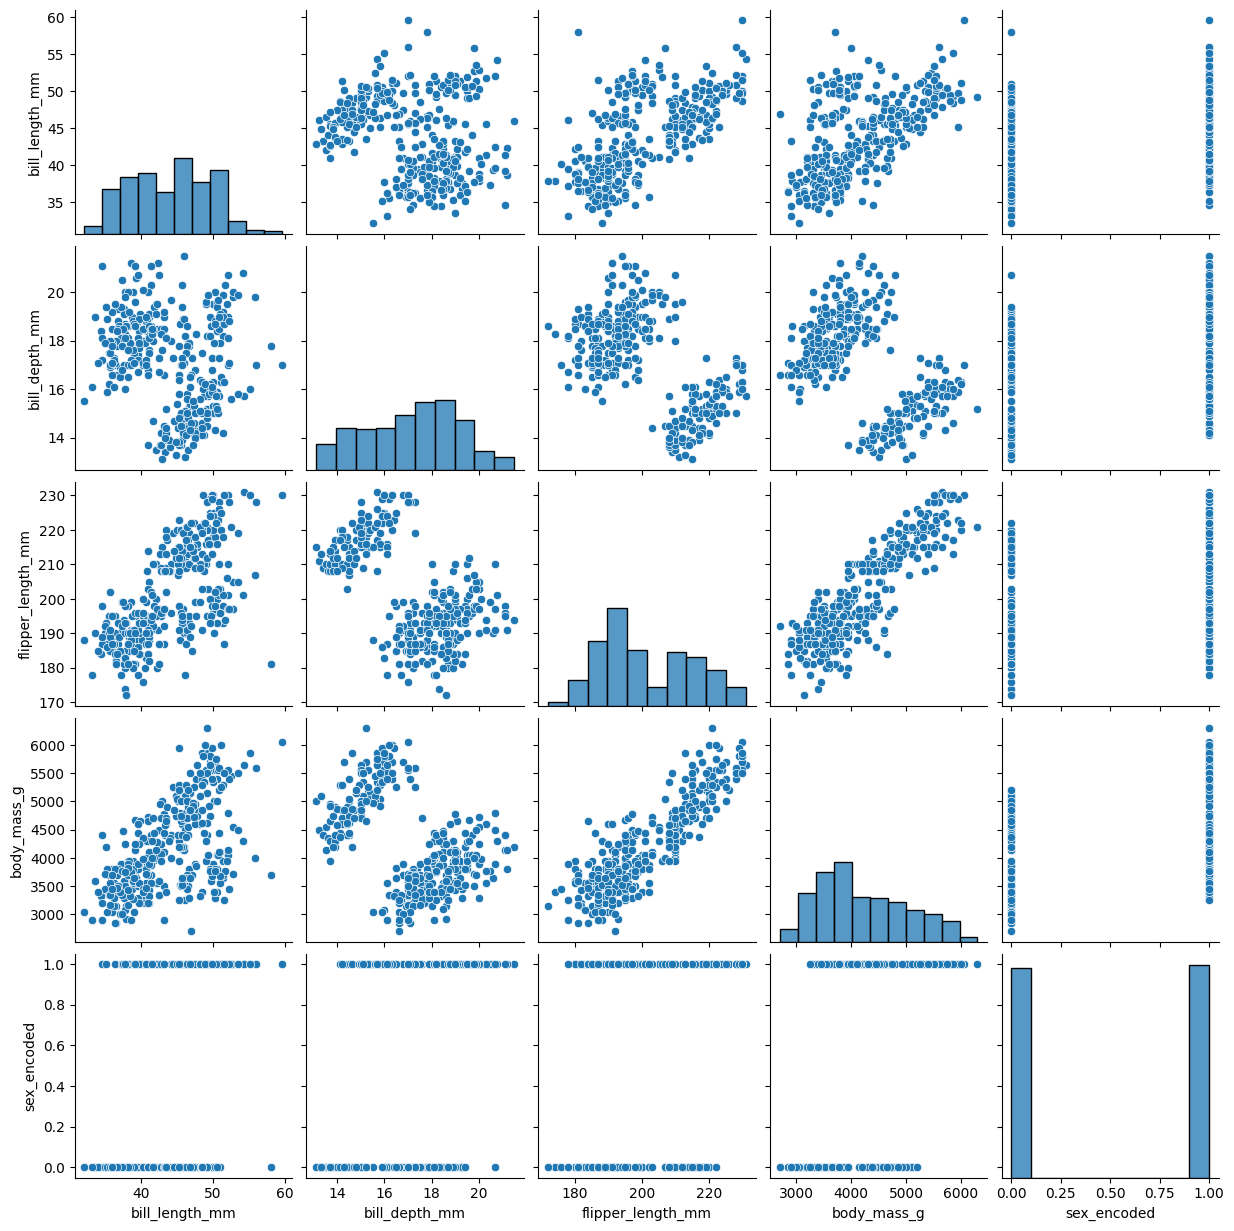

In [11]:
sns.pairplot(penguins)

É possível identificar clusterização em alguns dos pltos.
As mais evidentes são entre a espessura (altura) do bico e massa corporal e entre a espessura do bico e o comprimento da nadadeira

Com menos expressão, é possível identificar agrupamento entre espessura do bico e comprimento do bico.

A distribuição dessas características no gênero não apresentam nenhum agrupamento além do próprio gênero. Para todas elas é possível ver uma distribuição uniforme e muito similar entre os dois gêneros.

A distribuição de massa corporal e comprimento da nadadeira parece ser linear. 

A distribuição entre comprimento do bico e o comprimento da nadadeira, bem como em relação a massa corporal, não tem um comportamento bem definido. Pode representar um possível agrupamento, ou um comportamento linear.

# 3 - Realize a padronização dos dados e visualize os dados.

Ao rodar o modelo, encontrei problemas em inverter o campo `sex`. Como ele não mostrou nenhuma contribuição aparente em nenhum agrupamento, optei por o excluir da base.

In [12]:
penguins.drop(columns=['sex_encoded'], inplace=True)

In [13]:
penguins_padrao = penguins.copy()
colunas_padronizar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
scaler = StandardScaler()
penguins_padrao[colunas_padronizar] = scaler.fit_transform(penguins_padrao[colunas_padronizar])

In [14]:
penguins_padrao.head(5)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
4,-1.335566,1.085877,-0.569284,-0.941606
5,-0.859415,1.747026,-0.783651,-0.692852


In [15]:
fig = px.scatter(penguins_padrao, x='bill_depth_mm', y='body_mass_g',
                 title='Gráfico de Dispersão: Espessura do bico vs. Massa Corporal',
                 labels={'bill_depth_mm': 'Espessura do bico (mm)', 'body_mass_g': 'Massa Corporal (g)'})

fig.show()

# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [17]:
kmeans_perfil_penguins = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans_perfil_penguins.fit(penguins_padrao)
centroides = kmeans_perfil_penguins.cluster_centers_
centroides


c:\Users\marina.freitas\AppData\Local\anaconda3\envs\ebac\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



array([[-1.04680889,  0.48662566, -0.88169491, -0.7627539 ],
       [ 0.65475809, -1.10270671,  1.16246305,  1.10121078],
       [ 0.67202511,  0.80526339, -0.28934658, -0.38410387]])

In [18]:
centroides_padrao = kmeans_perfil_penguins.cluster_centers_  # Centroides padronizados retornados pelo k-means
centroides_padrao

array([[-1.04680889,  0.48662566, -0.88169491, -0.7627539 ],
       [ 0.65475809, -1.10270671,  1.16246305,  1.10121078],
       [ 0.67202511,  0.80526339, -0.28934658, -0.38410387]])

In [ ]:
# Inverter a padronização para obter os centroides originais

centroides_originais = scaler.inverse_transform(centroides_padrao)
centroides_originais


array([[  38.27674419,   18.12170543,  188.62790698, 3593.79844961],
       [  47.56806723,   14.99663866,  217.23529412, 5092.43697479],
       [  47.66235294,   18.74823529,  196.91764706, 3898.23529412]])

In [20]:
labels = kmeans_perfil_penguins.labels_
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [21]:
centroides_originais
labels = kmeans_perfil_penguins.labels_
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

In [23]:
# Criando um df com os dados originais e  rótulos de cluster
penguins_clusters = pd.DataFrame({
    'bill_depth_mm': penguins['bill_depth_mm'],
    'bill_length_mm': penguins['bill_length_mm'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(penguins_clusters, x='bill_depth_mm', y='bill_length_mm', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters de Perfil de Pinguins',)

# Adicionar os centroides ao gráfico

# colunas_padronizar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


fig.add_scatter(x=centroides_originais[:, 1], y=centroides_originais[:, 0],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')

fig.update_layout(xaxis_title='Bill Depth (mm)', yaxis_title='Bill Length (mm)',
                  legend_title='Cluster')
fig.show()

In [24]:
# Criando um df com os dados originais e  rótulos de cluster
penguins_clusters = pd.DataFrame({
    'bill_depth_mm': penguins['bill_depth_mm'],
    'body_mass_g': penguins['body_mass_g'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(penguins_clusters, x='bill_depth_mm', y='body_mass_g', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters de Perfil de Pinguins',)
# colunas_padronizar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_originais[:, 1], y=centroides_originais[:, 3],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')

fig.update_layout(xaxis_title='Bill Depth (mm)', yaxis_title='Body Mass (g)',
                  legend_title='Cluster')
fig.show()

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

1. Compressão e Redução de Dimensionalidade em Imagens

Algoritmos de clusterização podem ser usados para reduzir o número de cores em uma imagem (quantização de cores). Isso ajuda na compressão de imagens, deixando arquivos mais leves sem perder muita qualidade visual. Também pode ser usado em visão computacional para destacar regiões semelhantes em uma imagem.

2. **Agrupamento de Documentos e Textos**

Na análise de grandes volumes de dados textuais (artigos, notícias, posts em redes sociais), algoritmos como K-Means podem agrupar documentos por similaridade de conteúdo. Ex.: separar automaticamente notícias em categorias como política, esportes e tecnologia, revisão da literatura.

3. **Detecção de Anomalias em Dados**

Clusters podem revelar padrões “normais” nos dados, e pontos que ficam muito afastados dos grupos podem ser considerados anomalias. Ex.: em sistemas bancários, ajuda a detectar transações suspeitas ou fraudes.
